# 06 — Autoencoder for Fraud Anomaly Detection

This notebook builds the Autoencoder experiment used in the project.

Methodology:
- CPU-first PyTorch implementation
- 78 input features (`step` removed)
- Architecture: `78 → 32 → 12 → 32 → 78`
- Reconstruction error (MSE) as anomaly score
- Thresholds selected only on validation
- Final evaluation on the untouched test set
- Model, scores, thresholds, configuration and metrics saved at the end


In [1]:
from pathlib import Path
import json
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from scipy import sparse

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)


PyTorch version: 2.13.0+cpu
Device: cpu


## Paths

In [2]:
PROCESSED_PATH = Path("../data/processed")
MODELS_PATH = Path("../models")
RESULTS_PATH = Path("../results")
SCORES_PATH = RESULTS_PATH / "scores"
METRICS_PATH = RESULTS_PATH / "metrics"

MODELS_PATH.mkdir(parents=True, exist_ok=True)
SCORES_PATH.mkdir(parents=True, exist_ok=True)
METRICS_PATH.mkdir(parents=True, exist_ok=True)


## Load preprocessed data

In [3]:
X_train = sparse.load_npz(PROCESSED_PATH / "X_train.npz")
X_valid = sparse.load_npz(PROCESSED_PATH / "X_valid.npz")
X_test = sparse.load_npz(PROCESSED_PATH / "X_test.npz")

y_train = np.load(PROCESSED_PATH / "y_train.npy")
y_valid = np.load(PROCESSED_PATH / "y_valid.npy")
y_test = np.load(PROCESSED_PATH / "y_test.npy")

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (374914, 79) (374914,)
Valid: (108423, 79) (108423,)
Test : (111306, 79) (111306,)


## Remove the absolute `step` feature

In [4]:
with open(MODELS_PATH / "feature_names.json", "r") as f:
    feature_names = json.load(f)

print("Number of features:", len(feature_names))
print(feature_names[:10])


Number of features: 79
['num__step', 'num__amount_log', 'cat__age_0', 'cat__age_1', 'cat__age_2', 'cat__age_3', 'cat__age_4', 'cat__age_5', 'cat__age_6', 'cat__age_U']


In [5]:
step_feature = "num__step"
step_index = feature_names.index(step_feature)

print("step index:", step_index)

keep_indices = [i for i in range(len(feature_names)) if i != step_index]
autoencoder_feature_names = [feature_names[i] for i in keep_indices]

X_train_ae = X_train[:, keep_indices]
X_valid_ae = X_valid[:, keep_indices]
X_test_ae = X_test[:, keep_indices]

print("Train:", X_train_ae.shape)
print("Valid:", X_valid_ae.shape)
print("Test :", X_test_ae.shape)


step index: 0
Train: (374914, 78)
Valid: (108423, 78)
Test : (111306, 78)


## Convert sparse matrices to dense float32 arrays

In [6]:
X_train_dense = X_train_ae.toarray().astype(np.float32)
X_valid_dense = X_valid_ae.toarray().astype(np.float32)
X_test_dense = X_test_ae.toarray().astype(np.float32)

print(X_train_dense.shape, X_train_dense.dtype)
print(X_valid_dense.shape, X_valid_dense.dtype)
print(X_test_dense.shape, X_test_dense.dtype)

X_train_tensor = torch.from_numpy(X_train_dense)
X_valid_tensor = torch.from_numpy(X_valid_dense)
X_test_tensor = torch.from_numpy(X_test_dense)


(374914, 78) float32
(108423, 78) float32
(111306, 78) float32


## DataLoaders

In [7]:
BATCH_SIZE = 1024

train_dataset = TensorDataset(X_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor)

train_generator = torch.Generator()
train_generator.manual_seed(RANDOM_STATE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    generator=train_generator
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(valid_loader))


Training batches: 367
Validation batches: 106


## Autoencoder architecture

In [8]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 12),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(12, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed


In [9]:
INPUT_DIM = X_train_dense.shape[1]

autoencoder = Autoencoder(input_dim=INPUT_DIM).to(device)
autoencoder


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=78, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=12, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=78, bias=True)
  )
)

## Loss and optimizer

In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=1e-3
)


## Train with early stopping

In [11]:
MAX_EPOCHS = 20
PATIENCE = 3

best_valid_loss = np.inf
best_model_state = None
epochs_without_improvement = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    autoencoder.train()

    train_loss_sum = 0.0
    train_samples = 0

    for (batch_x,) in train_loader:
        batch_x = batch_x.to(device)
        optimizer.zero_grad()
        reconstructed = autoencoder(batch_x)
        loss = criterion(reconstructed, batch_x)
        loss.backward()
        optimizer.step()

        batch_size = batch_x.size(0)
        train_loss_sum += loss.item() * batch_size
        train_samples += batch_size

    train_loss = train_loss_sum / train_samples

    autoencoder.eval()
    valid_loss_sum = 0.0
    valid_samples = 0

    with torch.no_grad():
        for (batch_x,) in valid_loader:
            batch_x = batch_x.to(device)
            reconstructed = autoencoder(batch_x)
            loss = criterion(reconstructed, batch_x)

            batch_size = batch_x.size(0)
            valid_loss_sum += loss.item() * batch_size
            valid_samples += batch_size

    valid_loss = valid_loss_sum / valid_samples

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss: {train_loss:.6f} | "
        f"Valid loss: {valid_loss:.6f}"
    )

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_model_state = copy.deepcopy(autoencoder.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print("\nEarly stopping.")
            break


Epoch 01 | Train loss: 0.023925 | Valid loss: 0.003630
Epoch 02 | Train loss: 0.002733 | Valid loss: 0.002006
Epoch 03 | Train loss: 0.002040 | Valid loss: 0.001795
Epoch 04 | Train loss: 0.001768 | Valid loss: 0.001459
Epoch 05 | Train loss: 0.001480 | Valid loss: 0.001349
Epoch 06 | Train loss: 0.001375 | Valid loss: 0.001261
Epoch 07 | Train loss: 0.001323 | Valid loss: 0.001232
Epoch 08 | Train loss: 0.001295 | Valid loss: 0.001208
Epoch 09 | Train loss: 0.001278 | Valid loss: 0.001202
Epoch 10 | Train loss: 0.001269 | Valid loss: 0.001195
Epoch 11 | Train loss: 0.001260 | Valid loss: 0.001207
Epoch 12 | Train loss: 0.001252 | Valid loss: 0.001191
Epoch 13 | Train loss: 0.001243 | Valid loss: 0.001171
Epoch 14 | Train loss: 0.001234 | Valid loss: 0.001160
Epoch 15 | Train loss: 0.001225 | Valid loss: 0.001154
Epoch 16 | Train loss: 0.001216 | Valid loss: 0.001151
Epoch 17 | Train loss: 0.001210 | Valid loss: 0.001139
Epoch 18 | Train loss: 0.001205 | Valid loss: 0.001137
Epoch 19 |

## Restore best validation checkpoint

In [12]:
autoencoder.load_state_dict(best_model_state)
autoencoder.eval()
print(f"Best validation loss: {best_valid_loss:.6f}")


Best validation loss: 0.001135


## Training history

In [13]:
history_df = pd.DataFrame(history)
history_df


,epoch,train_loss,valid_loss
0,1,0.023925,0.003630
1,2,0.002733,0.002006
2,3,0.002040,0.001795
3,4,0.001768,0.001459
4,5,0.001480,0.001349
5,6,0.001375,0.001261
6,7,0.001323,0.001232
7,8,0.001295,0.001208
8,9,0.001278,0.001202
9,10,0.001269,0.001195


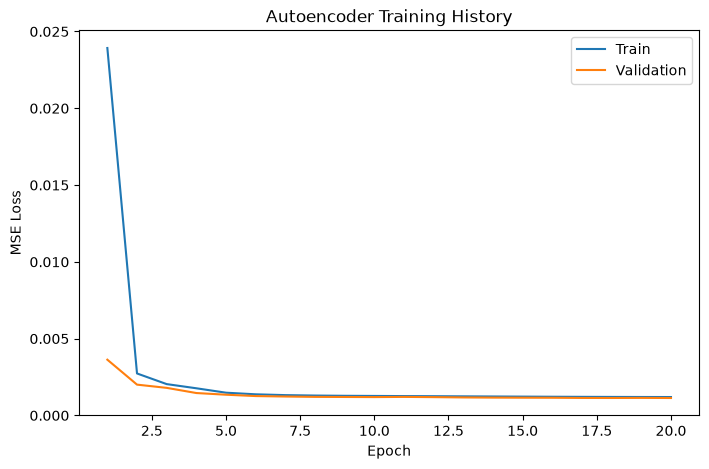

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train")
plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training History")
plt.legend()
plt.show()


## Reconstruction error as anomaly score

In [15]:
def reconstruction_errors(model, X_tensor, batch_size=4096):
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    scores = []
    model.eval()

    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            reconstructed = model(batch_x)
            batch_scores = torch.mean(
                (reconstructed - batch_x) ** 2,
                dim=1
            )
            scores.append(batch_scores.cpu().numpy())

    return np.concatenate(scores)


In [16]:
valid_scores_ae = reconstruction_errors(autoencoder, X_valid_tensor)
test_scores_ae = reconstruction_errors(autoencoder, X_test_tensor)

print("Validation scores:", valid_scores_ae.shape)
print("Test scores:", test_scores_ae.shape)


Validation scores: (108423,)
Test scores: (111306,)


## Score distribution by fraud label

In [17]:
valid_score_analysis = pd.DataFrame({
    "fraud": y_valid,
    "reconstruction_error": valid_scores_ae
})

valid_score_analysis.groupby("fraud")["reconstruction_error"].describe()


,count,mean,std,min,25%,50%,75%,max
fraud,,,,,,,,
0,107223.0,0.000989,0.003745,0.000013,0.000015,0.000019,0.000024,0.051590
1,1200.0,0.014191,0.008352,0.000024,0.007725,0.012072,0.024055,0.055029


In [18]:
test_score_analysis = pd.DataFrame({
    "fraud": y_test,
    "reconstruction_error": test_scores_ae
})

test_score_analysis.groupby("fraud")["reconstruction_error"].describe()


,count,mean,std,min,25%,50%,75%,max
fraud,,,,,,,,
0,110106.0,0.000990,0.003733,0.000013,0.000015,0.000019,0.000023,0.053862
1,1200.0,0.014107,0.008112,0.000024,0.009837,0.012102,0.023819,0.050924


## Ranking metrics

In [19]:
valid_roc_auc_ae = roc_auc_score(y_valid, valid_scores_ae)
valid_pr_auc_ae = average_precision_score(y_valid, valid_scores_ae)
test_roc_auc_ae = roc_auc_score(y_test, test_scores_ae)
test_pr_auc_ae = average_precision_score(y_test, test_scores_ae)

print(f"Validation ROC-AUC : {valid_roc_auc_ae:.4f}")
print(f"Validation PR-AUC  : {valid_pr_auc_ae:.4f}")
print()
print(f"Test ROC-AUC       : {test_roc_auc_ae:.4f}")
print(f"Test PR-AUC        : {test_pr_auc_ae:.4f}")


Validation ROC-AUC : 0.9658
Validation PR-AUC  : 0.1801

Test ROC-AUC       : 0.9661
Test PR-AUC        : 0.1752


Historical reference from the lost run (new training may differ slightly):
- Validation ROC-AUC ≈ 0.9723
- Validation PR-AUC ≈ 0.1893
- Test ROC-AUC ≈ 0.9717
- Test PR-AUC ≈ 0.1802

Keep the metrics actually produced by the new run.


## Validation threshold — Max F1

In [20]:
precision_ae, recall_ae, thresholds_ae = precision_recall_curve(
    y_valid,
    valid_scores_ae
)

f1_scores_ae = (
    2 * precision_ae[:-1] * recall_ae[:-1]
    / (precision_ae[:-1] + recall_ae[:-1] + 1e-12)
)

best_index_ae = np.argmax(f1_scores_ae)
best_threshold_ae = thresholds_ae[best_index_ae]
best_precision_ae = precision_ae[best_index_ae]
best_recall_ae = recall_ae[best_index_ae]
best_f1_ae = f1_scores_ae[best_index_ae]

print(f"Best threshold : {best_threshold_ae:.6f}")
print(f"Precision      : {best_precision_ae:.4f}")
print(f"Recall         : {best_recall_ae:.4f}")
print(f"F1-score       : {best_f1_ae:.4f}")


Best threshold : 0.023565
Precision      : 0.3167
Recall         : 0.3125
F1-score       : 0.3146


## Validation threshold — High Recall

In [21]:
TARGET_RECALL = 0.80

precision_thresholds_ae = precision_ae[:-1]
recall_thresholds_ae = recall_ae[:-1]

candidate_indices = np.where(
    recall_thresholds_ae >= TARGET_RECALL
)[0]

best_recall_index_ae = candidate_indices[
    np.argmax(precision_thresholds_ae[candidate_indices])
]

recall80_threshold_ae = thresholds_ae[best_recall_index_ae]
recall80_precision_ae = precision_thresholds_ae[best_recall_index_ae]
recall80_recall_ae = recall_thresholds_ae[best_recall_index_ae]

recall80_f1_ae = (
    2 * recall80_precision_ae * recall80_recall_ae
    / (recall80_precision_ae + recall80_recall_ae + 1e-12)
)


In [22]:
ae_validation_thresholds = pd.DataFrame({
    "Strategy": ["Max F1", "Recall >= 80%"],
    "Threshold": [best_threshold_ae, recall80_threshold_ae],
    "Precision": [best_precision_ae, recall80_precision_ae],
    "Recall": [best_recall_ae, recall80_recall_ae],
    "F1": [best_f1_ae, recall80_f1_ae]
})

ae_validation_thresholds


,Strategy,Threshold,Precision,Recall,F1
0,Max F1,0.023565,0.316723,0.3125,0.314597
1,Recall >= 80%,0.005704,0.134393,0.9375,0.235085


## Apply frozen validation thresholds to the test set

In [23]:
y_test_pred_ae_f1 = (
    test_scores_ae >= best_threshold_ae
).astype(int)

y_test_pred_ae_r80 = (
    test_scores_ae >= recall80_threshold_ae
).astype(int)


## Evaluation helper

In [24]:
def evaluate_predictions(y_true, y_pred):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    false_positive_rate = fp / (fp + tn)
    alert_rate = y_pred.mean()

    return {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positive Rate": false_positive_rate,
        "Alert Rate": alert_rate,
        "True Positives": tp,
        "False Positives": fp,
        "False Negatives": fn,
        "True Negatives": tn
    }


## Final test evaluation

In [25]:
results_ae_f1 = evaluate_predictions(
    y_test,
    y_test_pred_ae_f1
)

results_ae_r80 = evaluate_predictions(
    y_test,
    y_test_pred_ae_r80
)


In [26]:
ae_test_results = pd.DataFrame([
    {
        "Strategy": "Max F1",
        "Precision": results_ae_f1["Precision"],
        "Recall": results_ae_f1["Recall"],
        "F1": results_ae_f1["F1"],
        "False Positive Rate": results_ae_f1["False Positive Rate"],
        "Alert Rate": results_ae_f1["Alert Rate"]
    },
    {
        "Strategy": "Recall >= 80%",
        "Precision": results_ae_r80["Precision"],
        "Recall": results_ae_r80["Recall"],
        "F1": results_ae_r80["F1"],
        "False Positive Rate": results_ae_r80["False Positive Rate"],
        "Alert Rate": results_ae_r80["Alert Rate"]
    }
])

ae_test_results


,Strategy,Precision,Recall,F1,False Positive Rate,Alert Rate
0,Max F1,0.299396,0.289167,0.294192,0.007375,0.010413
1,Recall >= 80%,0.131844,0.939167,0.231227,0.067399,0.076797


In [27]:
for strategy, results in [
    ("Max F1", results_ae_f1),
    ("Recall >= 80%", results_ae_r80)
]:
    print(f"\n--- {strategy} ---")
    print("Frauds detected :", f"{results['True Positives']:,}")
    print("Frauds missed   :", f"{results['False Negatives']:,}")
    print("False alerts    :", f"{results['False Positives']:,}")
    print("True negatives  :", f"{results['True Negatives']:,}")



--- Max F1 ---
Frauds detected : 347
Frauds missed   : 853
False alerts    : 812
True negatives  : 109,294

--- Recall >= 80% ---
Frauds detected : 1,127
Frauds missed   : 73
False alerts    : 7,421
True negatives  : 102,685


## Save model

In [28]:
torch.save(
    autoencoder.state_dict(),
    MODELS_PATH / "autoencoder_state_dict.pt"
)

print("Autoencoder saved.")


Autoencoder saved.


## Save model configuration

In [29]:
autoencoder_config = {
    "input_dim": INPUT_DIM,
    "hidden_dim_1": 32,
    "bottleneck_dim": 12,
    "hidden_dim_2": 32,
    "activation": "ReLU",
    "loss": "MSELoss",
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "random_state": RANDOM_STATE,
    "excluded_feature": "num__step"
}

with open(MODELS_PATH / "autoencoder_config.json", "w") as f:
    json.dump(autoencoder_config, f, indent=2)


## Save feature list

In [30]:
with open(MODELS_PATH / "autoencoder_feature_names.json", "w") as f:
    json.dump(autoencoder_feature_names, f, indent=2)


## Save validation and test anomaly scores

In [31]:
np.save(
    SCORES_PATH / "autoencoder_valid_scores.npy",
    valid_scores_ae
)

np.save(
    SCORES_PATH / "autoencoder_test_scores.npy",
    test_scores_ae
)

print("Autoencoder scores saved.")


Autoencoder scores saved.


## Save thresholds

In [32]:
thresholds_to_save = {
    "max_f1": {
        "threshold": float(best_threshold_ae),
        "validation_precision": float(best_precision_ae),
        "validation_recall": float(best_recall_ae),
        "validation_f1": float(best_f1_ae)
    },
    "high_recall": {
        "target_recall": TARGET_RECALL,
        "threshold": float(recall80_threshold_ae),
        "validation_precision": float(recall80_precision_ae),
        "validation_recall": float(recall80_recall_ae),
        "validation_f1": float(recall80_f1_ae)
    }
}

with open(MODELS_PATH / "autoencoder_thresholds.json", "w") as f:
    json.dump(thresholds_to_save, f, indent=2)


## Save metrics

In [33]:
ranking_metrics_ae = pd.DataFrame([
    {
        "Model": "Autoencoder",
        "Validation ROC-AUC": valid_roc_auc_ae,
        "Validation PR-AUC": valid_pr_auc_ae,
        "Test ROC-AUC": test_roc_auc_ae,
        "Test PR-AUC": test_pr_auc_ae
    }
])

ranking_metrics_ae.to_csv(
    METRICS_PATH / "autoencoder_ranking_metrics.csv",
    index=False
)

ae_test_results.to_csv(
    METRICS_PATH / "autoencoder_operational_metrics.csv",
    index=False
)

history_df.to_csv(
    METRICS_PATH / "autoencoder_training_history.csv",
    index=False
)

print("Metrics saved.")


Metrics saved.


## Final verification

In [34]:
print("MODEL")
print(MODELS_PATH / "autoencoder_state_dict.pt")

print("\nSCORES")
print(SCORES_PATH / "autoencoder_valid_scores.npy")
print(SCORES_PATH / "autoencoder_test_scores.npy")

print("\nMETRICS")
print(METRICS_PATH / "autoencoder_ranking_metrics.csv")
print(METRICS_PATH / "autoencoder_operational_metrics.csv")

print("\nDone.")


MODEL
..\models\autoencoder_state_dict.pt

SCORES
..\results\scores\autoencoder_valid_scores.npy
..\results\scores\autoencoder_test_scores.npy

METRICS
..\results\metrics\autoencoder_ranking_metrics.csv
..\results\metrics\autoencoder_operational_metrics.csv

Done.


## Conclusion

The Autoencoder is trained without fraud labels and uses reconstruction error as its anomaly score.

Threshold selection is performed only on validation labels, while the test set remains untouched until final evaluation.

The notebook persists all artifacts needed for future comparison and ensemble experiments.
